<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2024-2/Sesiones/Sesion_14_RandomForest_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest

## Introducción

Los árboles de decisión son modelos que se ajustan muy bien a los datos de entrenamiento; sin embargo, tienen una capacidad limitada para generalizar, lo que los hace susceptibles al **overfitting**, su principal desventaja.  
Para abordar este problema, se desarrolló el algoritmo **Random Forest**, que se basa en dos características principales:

1. Entrenamiento de múltiples árboles utilizando diferentes subconjuntos del conjunto de datos original.
2. Uso de la técnica de **bootstrapping** para generar los subconjuntos de datos para cada árbol.

---

## Bootstrapping en Random Forest

Dado un conjunto de datos con las siguientes características:

| Index | $y$          | $X_1$      | $X_2$      | $X_3$      | $X_4$      |
|-------|--------------|------------|------------|------------|------------|
| 1     | $y^{(1)}$    | $X_1^{1}$  | $X_2^{1}$  | $X_3^{1}$  | $X_4^{1}$  |
| 2     | $y^{(2)}$    | $X_1^{2}$  | $X_2^{2}$  | $X_3^{2}$  | $X_4^{2}$  |
| 3     | $y^{(3)}$    | $X_1^{3}$  | $X_2^{3}$  | $X_3^{3}$  | $X_4^{3}$  |
| 4     | $y^{(4)}$    | $X_1^{4}$  | $X_2^{4}$  | $X_3^{4}$  | $X_4^{4}$  |

### Muestreo para los árboles
El número de árboles en el bosque y los datos que ingresan a cada árbol son hiperparámetros que pueden definirse. Para generar los subconjuntos de datos, se emplea **bootstrapping**, una técnica de muestreo con reposición.

Por ejemplo, si se generan subconjuntos de datos para 10 árboles, el muestreo con reposición podría producir algo como:

```python
import numpy as np
np.random.randint(0, 4, (10, 4))

Salida hipotética

array([[1, 0, 3, 3],
       [2, 1, 2, 0],
       [2, 3, 3, 3],
       [0, 2, 2, 3],
       [2, 0, 3, 3],
       [1, 1, 2, 0],
       [2, 2, 1, 2],
       [3, 0, 1, 0],
       [3, 1, 0, 2],
       [2, 0, 2, 0]])
```
Cada fila del array representa los índices seleccionados para entrenar un árbol. Por ejemplo, el árbol 1 se entrenará con los datos $X_1$, $X_2$, $X_3$, $X_4$ correspondientes a los índices [1, 0, 3, 3].


# Construcción de los Árboles

## Selección aleatoria de características
- En cada nodo de un árbol, se selecciona un subconjunto aleatorio de características para dividir los datos.

## Agregación de árboles
- Una vez entrenados todos los árboles, se combinan mediante un proceso de **agregación**.  
  Cuando se pasa un nuevo dato, cada árbol emite una clasificación, y la decisión final se toma por mayoría de votos.

---

# Relación entre Bagging y Random Forest

- **Bagging:** Combina **agregación** y **bootstrapping**.
- **Random Forest:** Es una extensión de bagging con selección aleatoria de características en cada nodo.

---

# Optimización de Random Forest

La estrategia para optimizar un Random Forest incluye los siguientes pasos:

1. **Fijar el número de árboles y evaluar el error:**  
   Determinar el error como función del número de árboles en el bosque.

2. **Ajustar el número de características:**  
   Con un número fijo de árboles, calcular el error como función del número de características seleccionadas en cada nodo.

3. **Optimizar el criterio de parada:**  
   Ajustar parámetros como el número mínimo de datos en una hoja para reducir el error y mejorar la generalización.

---

# Ventajas de Random Forest

- Reduce el riesgo de overfitting al promediar múltiples árboles.
- Permite identificar las características más importantes del conjunto de datos.

---

# Referencias

1. [Codificando Bits - Random Forest](https://www.youtube.com/watch?v=3pa0vtW64Ic&ab_channel=CodificandoBits)
2. [Wikipedia - Bootstrap Aggregating](https://en.wikipedia.org/wiki/Bootstrap_aggregating)
3. [Random Forest Book](http://www.cs.cmu.edu/~qyj/papersA08/11-rfbook.pdf)
4. [Hands-On Machine Learning](https://github.com/ageron/handson-ml2/blob/master/07_ensemble_learning_and_random_forests.ipynb)


In [ ]:
#https://github.com/ageron/handson-ml2/blob/master/07_ensemble_learning_and_random_forests.ipynb

In [ ]:
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles
from sklearn.datasets import make_classification
from sklearn.datasets import make_blobs
import matplotlib.pylab as plt

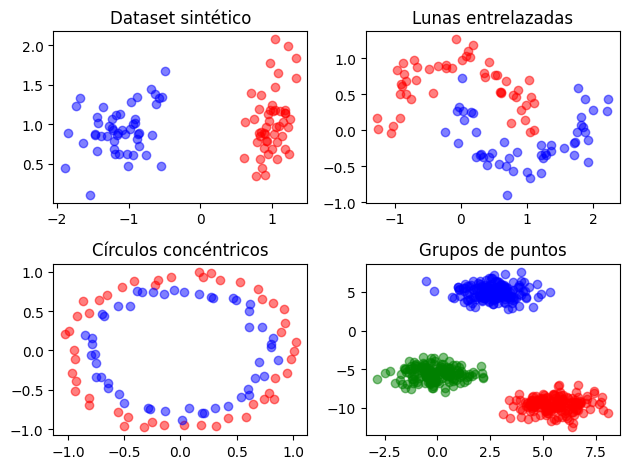

In [ ]:
# Dataset Toys References
# https://scikit-learn.org/stable/datasets/toy_dataset.html
# https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html
# Dataset sinteticos
X0, y0 = make_classification(
    n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1)
X1, y1 = make_moons(n_samples=100, noise=0.15, shuffle=True,  random_state=1)
X2, y2 = make_circles(n_samples=100, noise=0.05, shuffle=True,  random_state=1)
X3, y3 = make_blobs(n_samples=500, centers=3, n_features=2, shuffle=True, random_state=10)

fig, axs = plt.subplots(2,2)

axs[0, 0].set_title("Dataset sintético")
axs[0, 0].plot(X0[:,0][y0==0], X0[:,1][y0==0],"ro", alpha=0.5)
axs[0, 0].plot(X0[:,0][y0==1], X0[:,1][y0==1],"bo", alpha=0.5)

# Dataset a moons
axs[0, 1].set_title("Lunas entrelazadas")
axs[0, 1].plot(X1[:,0][y1==0], X1[:,1][y1==0],"ro", alpha=0.5)
axs[0, 1].plot(X1[:,0][y1==1], X1[:,1][y1==1],"bo", alpha=0.5)

# Dataset circles
axs[1, 0].set_title("Círculos concéntricos")
axs[1, 0].plot(X2[:,0][y2==0], X2[:,1][y2==0],"ro", alpha=0.5)
axs[1, 0].plot(X2[:,0][y2==1], X2[:,1][y2==1],"bo", alpha=0.5)

# Dataset circles
axs[1, 1].set_title("Grupos de puntos")
axs[1, 1].plot(X3[:,0][y3==0], X3[:,1][y3==0],"ro", alpha=0.5)
axs[1, 1].plot(X3[:,0][y3==1], X3[:,1][y3==1],"bo", alpha=0.5)
axs[1, 1].plot(X3[:,0][y3==2], X3[:,1][y3==2],"go", alpha=0.5)

fig.tight_layout()

## Clase `RandomForestClassifier`

construye muchos árboles de decisión y promedia (o vota) sus resultados. La idea principal es reducir la varianza (riesgo de sobreajuste) que suele presentar un único árbol de decisión, a costa de un ligero aumento en el sesgo y del costo computacional adicional.

**Parámetros:**

* `n_estimators (int, 100)`: Número de árboles en el bosque. Cuantos más árboles, mayor estabilidad de la predicción (disminuye la varianza), pero mayor costo computacional.

* `criterion (str, 'gini)`: Métrica de impureza.

* `max_depth (int, None)`: Profundidad máxima de los árboles.

* `max_features (int, float, str, None, 'sqrt)`: Número de características que se consideran al buscar la mejor división en cada nodo.

* `min_samples_leaf (int, float, 1)`: Mínimo número de muestras que debe tener un nodo hoja.

* `bootstrap (bool, True)`: Activación de muestreo con reemplazo.

  * Si es `False` se usan los mismos datos de entrenamiento completos para cada árbol (`max_features < n_features`).

* `oob_score (bool, False)`:

  * `True`: calcula la puntuación del ensamble usando las muestras “fuera de bolsa” (**out-of-bag**), aquellas que no fueron incluidas en la muestra bootstrap de cada árbol (datos de test del subconjunto).

  * `False`: Puede servir como una estimación de generalización sin usar un set de validación adicional.

\
**Atributos:**

* `estimators_ (list DecisionTreeClassifier)`, `classes_`, `n_features_in_`

* `feature_importances_`: Importancia estimada de cada característica (basada en la reducción media de impureza a través de los árboles).

* `oob_score_`: (si oob_score=True) precisión estimada con las muestras fuera de bolsa.

* `oob_decision_function_`: (si oob_score=True) probabilidades de clasificación promedio en las muestras fuera de bolsa.

\
**Métodos:**

* `fit(X, y)`, `predict(X)`, `predict_proba(X)`, `score(X, y)`

* `decision_path(X)`: Devuelve, para cada árbol, la trayectoria de cada muestra a través de los nodos del árbol.




In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
X, y = make_classification(n_samples=1000, n_features=4, n_informative=2,
                           n_redundant=0, random_state=0, shuffle=False)

# Creamos el Bosque Aleatorio: 100 árboles, 2 hojas, bootstrap
# No usamos los sets fuera de la bolsa para testeo adicional
clf = RandomForestClassifier(max_depth=2, random_state=0)

# Preparamos con los datos
clf.fit(X, y)

print('Muestra X1, X2, X3, X4 = 0, 0, 0, 0')
print('Clase a la que puede pertenecer:', clf.predict([[0, 0, 0, 0]]))

Muestra X1, X2, X3, X4 = 0, 0, 0, 0
Clase a la que puede pertenecer: [1]


## Laboratorio con MNIST Dataset:

1. Cargar load digitis:

Base de datos de dígitos escritos a mano que se utiliza comúnmente para entrenar varios sistemas de procesamiento de imágenes

[Base de datos MNIST
](https://en.wikipedia.org/wiki/MNIST_database)

```python
  from sklearn.datasets import load_digits
  digits = load_digits()
  print(digits.data.shape)

  import matplotlib.pyplot as plt
  plt.gray()
  plt.matshow(digits.images[95])
  plt.show()
```

2. Aplicar **Random Forest** usando sklearn

(1797, 64)


<Figure size 640x480 with 0 Axes>

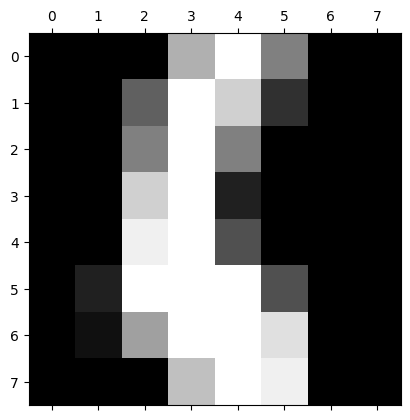

In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()
print(digits.data.shape)

import matplotlib.pyplot as plt
plt.gray()
plt.matshow(digits.images[95])
plt.show()

In [ ]:
# Solution 1 GPT 3
# escribir código en python para clasificador usar forset aleatorio con MNIST Dataset

# RandomForest -> max_depth=None, bootstrap, out_of_bag False
clf = RandomForestClassifier(n_estimators=100)
clf.fit(digits.data, digits.target)

# to test
print('Filas: \n\t', clf.predict(digits.data[-5:]))    # últimas 5 filas
print('\t', digits.target[-5:])

print('\nImportancia de cada característica basada en la reducción de impureza:\n:::')
clf.feature_importances_

Filas: 
	 [9 0 8 9 8]
	 [9 0 8 9 8]

Importancia de cada característica basada en la reducción de impureza:
:::


array([0.00000000e+00, 1.60984496e-03, 2.05167311e-02, 1.12784229e-02,
       9.11783646e-03, 1.99619018e-02, 7.18165229e-03, 6.00934649e-04,
       7.83947077e-05, 1.18496379e-02, 2.68878396e-02, 7.45278771e-03,
       1.62105386e-02, 2.61888684e-02, 5.32292177e-03, 6.25218442e-04,
       3.67076931e-05, 6.38247195e-03, 2.13125982e-02, 2.44584038e-02,
       2.80873445e-02, 4.93408496e-02, 9.15198287e-03, 2.29062008e-04,
       6.88979280e-05, 1.31063714e-02, 4.40164390e-02, 2.33187912e-02,
       2.99916209e-02, 2.38895796e-02, 3.22621488e-02, 8.04316764e-05,
       0.00000000e+00, 3.24171285e-02, 2.70644647e-02, 1.67970281e-02,
       4.13523335e-02, 2.07253757e-02, 2.51129015e-02, 0.00000000e+00,
       0.00000000e+00, 1.06686809e-02, 4.02608849e-02, 4.37726763e-02,
       2.06305496e-02, 1.73963619e-02, 1.94585679e-02, 3.86805763e-05,
       5.90635642e-05, 2.27084657e-03, 1.55492299e-02, 2.27903700e-02,
       1.41972667e-02, 2.20625030e-02, 2.25755316e-02, 1.82795646e-03,
      

## Procedimiento de clasificación y predicción de clases

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

### Clase `KNeighborsClassifier`

El **k-NN** es un método de aprendizaje perezoso (lazy learning), pues no construye un modelo explícito durante el entrenamiento. En su lugar, para clasificar una nueva muestra, el algoritmo:

1. Localiza sus k vecinos más próximos en el conjunto de entrenamiento (según cierta distancia).

2. Predice la clase mayoritaria (o ponderada) de esos vecinos.

**Parámetros:**

* `n_neighbors (int, 5)`: Número de vecinos a considerar. Controla el tamaño del vecindario que se consulta para asignar la clase.

* `weights (str, callable, 'uniform)`: Cómo ponderar la contribución de cada vecino:

  * `'uniform'`: todos los vecinos aportan el mismo peso a la hora de votar.

  * `'distance'`: el voto de cada vecino se pondera inversamente con la distancia (los vecinos más cercanos tienen más peso).

  * También puede proporcionarse una función personalizada que reciba las distancias y devuelva los pesos.

* `algorithm ('auto)`: Estructura de búsqueda para encontrar los vecinos más cercanos.

  * `'ball_tree'`: usa un Ball Tree.
  * `'kd_tree'`: usa un KD Tree.
  * `'brute'`: búsqueda por fuerza bruta.
  * `'auto'`: elige automáticamente según el tipo y tamaño de datos.

* `metric (str, callable, 'minkowski')`: Tipo de métrica de distancia a usar (euclídea, manhattan, canberra, etc.).

\
**Atributos:**

* `classes_`: lista de clases en la clasificación.

* `effective_metric_`: métrica real usada (puede diferir si se selecciona 'auto').

* `n_features_in_`: número de características usadas en fit.

* `n_samples_fit_`: número de muestras en los datos de entrenamiento guardados para las consultas de vecinos.

\
**Métodos:**

* `fit(X, y)`, `predict(X)`, `predict_proba(X)`, `score(X, y)`

\
**Nota:** Su uso es muy sencillo (basta con fit y predict), y no requiere entrenamiento intensivo, pero las consultas pueden ser costosas en datasets grandes. Además, funciona mejor cuando los datos están adecuadamente escalados y no tienen una dimensionalidad excesiva.

In [ ]:
# Lectura de los datos de MNIST
mnist = fetch_openml('mnist_784')
X, y = mnist["data"], mnist["target"]

# Extraemos datos de entrenamiento y prueba
def train_test_split(X, y, test_ratio):
    shuffled_indices = np.random.permutation(len(X))
    test_set_size = int(len(X) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return X.loc[train_indices], y.loc[train_indices], X.loc[test_indices], y.loc[test_indices]

train_set, train_labels, test_set, test_labels = train_test_split(X, y, test_ratio=0.2)

# Entrenamos el modelo de Random Forest
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(train_set, train_labels)

# forest_clf.predict([some_digit])
# forest_clf.predict_proba([some_digit])

# Realizamos una validación cruzada con el modelo de Random Forest
score_RF = cross_val_score(forest_clf, train_set, train_labels, cv=3, scoring="accuracy")
print('Score Random Forest:', score_RF)

# Entrenamos un modelo de vecinos: KNeigbors
knn_clf = KNeighborsClassifier()
knn_clf.fit(train_set, train_labels)
# knn_clf.predict([some_digit])
knn_clf.score(test_set, test_labels)

score_KNN = cross_val_score(knn_clf, train_set, train_labels, cv=3, scoring="accuracy")
print('Score KNN:', score_KNN)

array([0.96683988, 0.96673274, 0.96689167])

In [ ]:
# Buscamos los parámetros que optimizan el estimador
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},   # Bootstrap activado
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
 ]

forest_clf = RandomForestClassifier()

# Evaluamos la calidad del modelo a partir de la métrica 'error cuadrático medio'
grid_search = GridSearchCV(forest_clf, param_grid, cv=5,
                           scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(train_set, train_labels)

print('Error Cuadrático Medio: ', np.sqrt(-grid_search.best_score_))

print('Mejor combinación de hiperparámetros:', grid_search.best_params_)

feature_importances = grid_search.best_estimator_.feature_importances_
print('Importancia de cada característica:', feature_importances)

KeyboardInterrupt: 